# 04 — Linear Classifiers: Scores and Geometry

A linear classifier assigns one score to every class using

$$s = Wx + b.
$$

This notebook focuses only on what those scores mean. We will not define a loss or learn the parameters yet.

## Learning objectives

- track the shapes of inputs, weights, biases, and scores;
- calculate class scores for one example and a batch;
- interpret each row of the weight matrix as one class-specific scoring rule;
- understand the bias trick using augmented vectors;
- derive pairwise linear decision boundaries;
- distinguish unnormalized scores from probabilities.

Companion note: [`notes/03-linear-classifiers/preview.md`](../notes/03-linear-classifiers/preview.md).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from torchvision.datasets import CIFAR10

SEED = 42
rng = np.random.default_rng(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

## 1. One example, three class scores

Begin with a grayscale image containing only four pixels. Flattening gives a feature vector with `D=4`. We want scores for `C=3` classes.

| quantity | meaning | shape |
|---|---|---|
| `x` | one flattened image | `(D,) = (4,)` |
| `W` | one weight row per class | `(C, D) = (3, 4)` |
| `b` | one bias per class | `(C,) = (3,)` |
| `scores` | one score per class | `(C,) = (3,)` |

In [2]:
x = np.array([56.0, 231.0, 24.0, 2.0])
W = np.array([
    [0.2, -0.5, 0.1, 2.0],   # cat scoring rule
    [1.5, 1.3, 2.1, 0.0],    # dog scoring rule
    [0.0, 0.25, 0.2, -0.3],  # ship scoring rule
])
b = np.array([1.1, 3.2, -1.2])
class_names_small = np.array(["cat", "dog", "ship"])

print("x shape:", x.shape)
print("W shape:", W.shape)
print("b shape:", b.shape)

x shape: (4,)
W shape: (3, 4)
b shape: (3,)


### Exercise 1 — Calculate scores explicitly

For each class, compute the dot product between its row of `W` and `x`, then add its bias. First calculate at least one score by hand. Complete the loop without calling `W @ x`.

In [4]:
scores_loop = np.empty(len(W))

for i in range(len(W)):
    scores_loop[i] = W[i] @ x + b[i]

expected_scores = np.array([-96.8, 437.9, 60.75])
np.testing.assert_allclose(scores_loop, expected_scores)

for class_name, score in zip(class_names_small, scores_loop):
    print(f"{class_name:>4}: {score:7.2f}")
print("predicted class:", class_names_small[np.argmax(scores_loop)])

 cat:  -96.80
 dog:  437.90
ship:   60.75
predicted class: dog


## 2. Vectorized score calculation

Matrix-vector multiplication calculates all class dot products at once:

$$
\underbrace{W}_{(C,D)}
\underbrace{x}_{(D,)}
+\underbrace{b}_{(C,)}
=\underbrace{s}_{(C,)}.
$$

The inner feature dimensions `D` match and disappear; the class dimension `C` remains.

In [5]:
scores_vectorized = W @ x + b
np.testing.assert_allclose(scores_vectorized, scores_loop)
print(scores_vectorized)

[-96.8  437.9   60.75]


### Exercise 2 — Read one score

Expand the ship score `W[2] @ x + b[2]` into four multiplication terms and one bias term in a Markdown cell. Then answer:

1. Which input pixel contributes most positively to the ship score?
2. Which contributes negatively?
3. Does the largest score represent a probability? Why not?

In [6]:
56.0*0.0 + 231.0*0.25 + 24.0*0.2 + 2.0*-0.3 - 1.2

60.74999999999999

1. second pixel (top-right)
2. 4th (botton-right)
3. no, probabilities are in range 0-1. Here we have not limited numeric value. Raw scores can be negative, exceed one, and do not necessarily sum to one. Therefore, they are not probabilities.

## 3. Score a batch

For a batch, it is convenient to store examples as rows in `X` with shape `(N, D)`. The equivalent score equation is

$$S=XW^T+b.
$$

Here `X @ W.T` has shape `(N, C)`. NumPy broadcasts `b` with shape `(C,)` across all `N` rows. Entry `S[i, c]` is the score of class `c` for example `i`.

In [7]:
X_small = np.array([
    [56.0, 231.0, 24.0, 2.0],
    [10.0, 20.0, 30.0, 40.0],
    [100.0, 0.0, 50.0, 5.0],
])

batch_scores = X_small @ W.T + b
print("X shape:", X_small.shape)
print("W.T shape:", W.T.shape)
print("scores shape:", batch_scores.shape)
print(batch_scores)

X shape: (3, 4)
W.T shape: (4, 3)
scores shape: (3, 3)
[[-96.8  437.9   60.75]
 [ 76.1  107.2   -2.2 ]
 [ 36.1  258.2    7.3 ]]


### Exercise 3 — Verify batch scoring

Add assertions demonstrating that:

1. the result has shape `(3, 3)`;
2. its first row equals the earlier single-example scores;
3. calculating each example separately produces the same matrix.

In [12]:
assert batch_scores.shape == (X_small.shape[0], W.shape[0])
assert np.allclose(batch_scores[0], scores_loop)

for i in range(X_small.shape[0]):
    assert np.allclose(batch_scores[i], W @ X_small[i] + b)

print("Exercise 3 passed")

Exercise 3 passed


## 4. The bias trick

The bias can be absorbed into the weight matrix by appending a constant feature equal to one:

$$
\tilde{x}=\begin{bmatrix}x\\1\end{bmatrix},\qquad
\tilde{W}=\begin{bmatrix}W&b\end{bmatrix}.
$$

Then `W_tilde @ x_tilde` equals `W @ x + b`. This is an algebraic convenience; keeping `W` and `b` separate is often clearer in code.

### Exercise 4 — Implement the bias trick

Construct `x_augmented` with shape `(5,)` and `W_augmented` with shape `(3, 5)` using NumPy concatenation. Verify that the resulting scores equal `scores_vectorized`.

In [47]:
bias_column = np.ones((W.shape[0], 1))
# x_augmented = np.concatenate([X_small, bias_column], axis=1)[0, :]
x_augmented = np.append(x, 1)  # Add bias term to the input vector
W_augmented = np.concatenate([W, b.reshape(-1, 1)], axis=1)

assert x_augmented.shape == (5,)
assert W_augmented.shape == (3, 5)
np.testing.assert_allclose(W_augmented @ x_augmented, scores_vectorized)
print("Exercise 4 passed")

Exercise 4 passed


In [49]:
b.shape, b.reshape(-1, 1).shape, bias_column.shape

((3,), (3, 1), (3, 1))

## 5. Geometric viewpoint in two dimensions

With two features, each class score is a plane:

$$s_c(x)=w_c^Tx+b_c.
$$

The predicted class is whichever plane is highest at a point. The boundary between classes `a` and `b` occurs where their scores are equal:

$$
(w_a-w_b)^Tx+(b_a-b_b)=0.
$$

In two dimensions this is a line; in `D` dimensions it is a hyperplane.

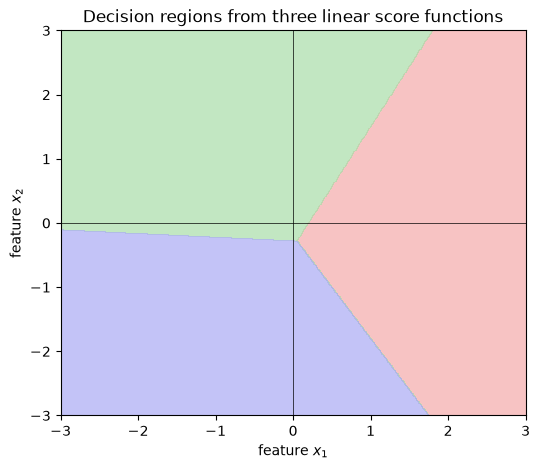

In [50]:
W_2d = np.array([
    [1.0, 0.2],
    [-0.5, 1.0],
    [-0.6, -0.8],
])
b_2d = np.array([0.0, 0.3, -0.2])
class_names_2d = np.array(["red", "green", "blue"])

grid_x1, grid_x2 = np.meshgrid(
    np.linspace(-3, 3, 400),
    np.linspace(-3, 3, 400),
)
grid_points = np.column_stack([grid_x1.ravel(), grid_x2.ravel()])
grid_scores = grid_points @ W_2d.T + b_2d
grid_predictions = np.argmax(grid_scores, axis=1).reshape(grid_x1.shape)

fig, axis = plt.subplots(figsize=(6, 5))
axis.contourf(
    grid_x1,
    grid_x2,
    grid_predictions,
    levels=[-0.5, 0.5, 1.5, 2.5],
    cmap=ListedColormap(["#f4aaaa", "#a9dda9", "#aaaaf4"]),
    alpha=0.7,
)
axis.set(
    xlabel="feature $x_1$",
    ylabel="feature $x_2$",
    title="Decision regions from three linear score functions",
)
axis.axhline(0, color="black", linewidth=0.5)
axis.axvline(0, color="black", linewidth=0.5)
plt.show()

### Exercise 5 — Derive and draw one boundary

For classes 0 and 1:

1. calculate `weight_difference = W_2d[0] - W_2d[1]`;
2. calculate `bias_difference = b_2d[0] - b_2d[1]`;
3. solve the equality for $x_2$ as a function of $x_1$;
4. draw that line over the decision-region plot;
5. verify numerically that both class scores are equal at several points on it.

Remember: parts of the infinite pairwise equality line may lie inside a region won by the third class, so not every point on it must be a visible final decision boundary.

In [61]:
W_2d[0] - W_2d[1], b_2d[0] - b_2d[1]

(array([ 1.5, -0.8]), np.float64(-0.3))

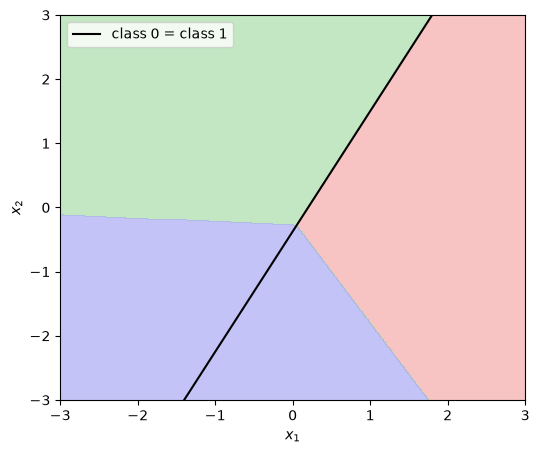

Exercise 5 passed


In [60]:
weight_difference = W_2d[0] - W_2d[1]
bias_difference = b_2d[0] - b_2d[1]
boundary_x1 = np.linspace(-3, 3, 100)
boundary_x2 = (-weight_difference[0] * boundary_x1 - bias_difference) / weight_difference[1]
boundary_points = np.column_stack([boundary_x1, boundary_x2])

boundary_scores = boundary_points @ W_2d.T + b_2d
np.testing.assert_allclose(boundary_scores[:, 0], boundary_scores[:, 1], atol=1e-10)

fig, axis = plt.subplots(figsize=(6, 5))
axis.contourf(
    grid_x1, grid_x2, grid_predictions,
    levels=[-0.5, 0.5, 1.5, 2.5],
    cmap=ListedColormap(["#f4aaaa", "#a9dda9", "#aaaaf4"]),
    alpha=0.7,
)
axis.plot(boundary_x1, boundary_x2, color="black", label="class 0 = class 1")
axis.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="$x_1$", ylabel="$x_2$")
axis.legend()
plt.show()
print("Exercise 5 passed")

### How the boundary coordinates are calculated

For classes 0 and 1, equal scores require

$$
(w_0-w_1)^Tx+(b_0-b_1)=0.
$$

Here `weight_difference = [1.5, -0.8]` and `bias_difference = -0.3`, so for $x=[x_1,x_2]$ the equation is

$$1.5x_1-0.8x_2-0.3=0.
$$

Solving for the vertical coordinate gives

$$x_2=\frac{1.5x_1-0.3}{0.8}=1.875x_1-0.375.
$$

In general, if `weight_difference = [a, c]` and the bias difference is `d`, then $ax_1+cx_2+d=0$ and

```python
boundary_x2 = -(a * boundary_x1 + d) / c
```

The boundary is an infinite line, but a plot needs finite coordinates. `np.linspace(-3, 3, 100)` selects 100 evenly spaced $x_1$ values across the visible horizontal range. The formula calculates the matching $x_2$ for each value. Two points would be sufficient to define a straight line; 100 points make the sampling approach explicit and also generalize to plotting curves.

## 6. Scores for real CIFAR-10 images

A CIFAR-10 image has `32 × 32 × 3 = 3072` raw-pixel features. For ten classes, `W` has shape `(10, 3072)` and `b` has shape `(10,)`.

The random parameters below demonstrate the mechanics only. Their predictions should not be meaningful because no loss has been minimized and nothing has been learned.

In [62]:
dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
sample_indices = rng.choice(len(dataset.data), size=8, replace=False)
sample_images = dataset.data[sample_indices]
sample_labels = np.asarray(dataset.targets)[sample_indices]
sample_features = sample_images.reshape(len(sample_images), -1).astype(np.float32)

num_classes = len(CLASS_NAMES)
num_features = sample_features.shape[1]
W_random = rng.normal(0, 0.001, size=(num_classes, num_features)).astype(np.float32)
b_random = np.zeros(num_classes, dtype=np.float32)
sample_scores = sample_features @ W_random.T + b_random
sample_predictions = np.argmax(sample_scores, axis=1)

print("features:", sample_features.shape)
print("weights:", W_random.shape)
print("biases:", b_random.shape)
print("scores:", sample_scores.shape)

features: (8, 3072)
weights: (10, 3072)
biases: (10,)
scores: (8, 10)


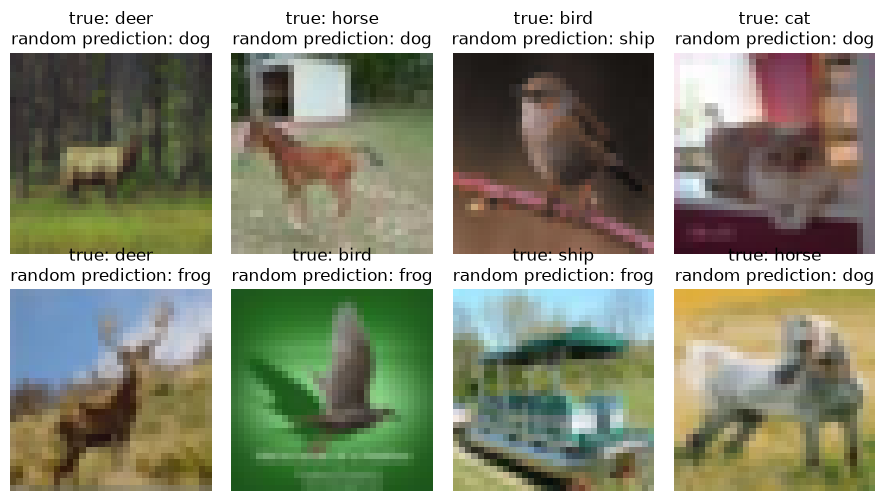

In [63]:
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for axis, image, target, prediction in zip(
    axes.flat, sample_images, sample_labels, sample_predictions
):
    axis.imshow(image)
    axis.set_title(
        f"true: {CLASS_NAMES[target]}\nrandom prediction: {CLASS_NAMES[prediction]}"
    )
    axis.axis("off")
plt.tight_layout()
plt.show()

## Reflection

Add a Markdown cell answering:

1. What does one row of `W` represent?
2. Why does `W @ x` produce one value per class?
3. How does the bias affect a class score and its decision boundaries?
4. For a batch stored as rows, why do we compute `X @ W.T` rather than `W @ X`?
5. Why are raw linear scores not probabilities?
6. What shape does the boundary between two classes have in 2D and in `D` dimensions?
7. Why should the random CIFAR-10 predictions have no semantic meaning?

Next we will define a loss function that measures whether the correct class score is sufficiently larger than the incorrect scores.

1. One row of \(W\) is the weight vector or scoring template for one class. Its dot product with the input measures compatibility between that class and the image.
2. if x is one flattened image then it is multiplied by each W row and number of W rows is number of classes
3. no bias means decision boundaries always goes through 0. The bias raises or lowers a class score independently of the input. Differences between class biases shift their pairwise decision boundaries. If all biases are zero, every pairwise linear boundary passes through the origin.
4. to match the dimensions properly and have correct one at the end - number of examples x number of classes. We do not care about number of features (pixels) at the end. \((N,D)(D,C)=(N,C)\) . W.T is needed because examples and class weight vectors are both stored as rows.
5. cause it is not limited by (0,1) range. Raw scores can be negative, exceed one, and do not necessarily sum to one. Therefore, they are not probabilities.
6. it's line in 2D, 3D feature space - a plane, \(D\)-dimensional space: a \((D-1)\)-dimensional hyperplane
7. it has not been trained. random parameters have not learned any relationship between pixels and labels